# **Titanic Crisis Analysis — TCA**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## df["Age"] --> float64 which is actually int64

In [4]:
df["Age"].values

array([22.  , 38.  , 26.  , 35.  , 35.  ,   nan, 54.  ,  2.  , 27.  ,
       14.  ,  4.  , 58.  , 20.  , 39.  , 14.  , 55.  ,  2.  ,   nan,
       31.  ,   nan, 35.  , 34.  , 15.  , 28.  ,  8.  , 38.  ,   nan,
       19.  ,   nan,   nan, 40.  ,   nan,   nan, 66.  , 28.  , 42.  ,
         nan, 21.  , 18.  , 14.  , 40.  , 27.  ,   nan,  3.  , 19.  ,
         nan,   nan,   nan,   nan, 18.  ,  7.  , 21.  , 49.  , 29.  ,
       65.  ,   nan, 21.  , 28.5 ,  5.  , 11.  , 22.  , 38.  , 45.  ,
        4.  ,   nan,   nan, 29.  , 19.  , 17.  , 26.  , 32.  , 16.  ,
       21.  , 26.  , 32.  , 25.  ,   nan,   nan,  0.83, 30.  , 22.  ,
       29.  ,   nan, 28.  , 17.  , 33.  , 16.  ,   nan, 23.  , 24.  ,
       29.  , 20.  , 46.  , 26.  , 59.  ,   nan, 71.  , 23.  , 34.  ,
       34.  , 28.  ,   nan, 21.  , 33.  , 37.  , 28.  , 21.  ,   nan,
       38.  ,   nan, 47.  , 14.5 , 22.  , 20.  , 17.  , 21.  , 70.5 ,
       29.  , 24.  ,  2.  , 21.  ,   nan, 32.5 , 32.5 , 54.  , 12.  ,
         nan, 24.  ,

In [5]:
df["Age"] = df["Age"].round(0).astype("Int64")

In [6]:
df["Age"].values

<IntegerArray>
[  22,   38,   26,   35,   35, <NA>,   54,    2,   27,   14,
 ...
   33,   22,   28,   25,   39,   27,   19, <NA>,   26,   32]
Length: 891, dtype: Int64

In [7]:
df["FamSize"] = df["SibSp"] + df["Parch"] + 1
df["FamSize"]
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamSize
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,<NA>,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C148,C,1


In [8]:
df = df.drop(columns=["SibSp", "Parch"])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,FamSize
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,<NA>,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26,111369,30.0000,C148,C,1


In [9]:
col = df.pop("FamSize")
df.insert(6,"FamSize",col)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,2,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,2,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,1,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,2,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,1,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,1,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,1,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,<NA>,4,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,1,111369,30.0000,C148,C


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
FamSize          0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.shape

(891, 11)

## Since 687 of 'Cabin' is null values of total 891 which is ***77.1%***

In [13]:
df = df.drop(columns="Cabin")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,2,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,2,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,1,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,2,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,1,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,1,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,1,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,<NA>,4,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,1,111369,30.0000,C


# Gender & Survival Rates

In [14]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
df["Sex"][(df["Survived"] == 1) & (df["Sex"] == "male")].count()

np.int64(109)

## ~18.9% Survival rate in TCA

In [16]:
df["Sex"][(df["Survived"] == 1) & (df["Sex"] == "female")].count()

np.int64(233)

## ~74.2% Survival rate in TCA

In [17]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

# Age & Survival Rates

In [18]:
((df["Age"] > 0) & (df["Age"] < 12)).sum()

np.int64(67)

In [19]:
df["Survived"][(df["Age"] > 0) & (df["Age"] < 12)].sum()

np.int64(38)

# ~56.7%

In [20]:
((df["Age"] > 13) & (df["Age"] < 20)).sum()

np.int64(93)

In [21]:
df["Survived"][(df["Age"] > 13) & (df["Age"] < 20)].sum()

np.int64(37)

# ~39.8%

In [22]:
((df["Age"] > 21) & (df["Age"] < 40)).sum()

np.int64(347)

In [23]:
df["Survived"][(df["Age"] > 21) & (df["Age"] < 40)].sum()

np.int64(142)

# ~40.9%

In [24]:
((df["Age"] > 41) & (df["Age"] < 90)).sum()

np.int64(142)

In [25]:
df["Survived"][(df["Age"] > 41) & (df["Age"] < 90)].sum()

np.int64(53)

# ~37.3%

In [26]:
# (df["Embarked"] == 'C').sum() / df["Survived"][df["Embarked"] == 'C'].sum() = df.groupby("Embarked")["Survived"].mean()

In [27]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [28]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

# Is survival rate among who embarked at C (Cherbourg) caused by the embarkation point itself?

In [29]:
df.groupby(["Embarked", "Pclass"]).size()

Embarked  Pclass
C         1          85
          2          17
          3          66
Q         1           2
          2           3
          3          72
S         1         127
          2         164
          3         353
dtype: int64

# Passenger Class & Survival

In [30]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

# Fare & Survival

In [31]:
df.groupby(pd.cut(df["Fare"], [0, 10, 30, 100, 600]))["Survived"].mean()

Fare
(0, 10]       0.205607
(10, 30]      0.433022
(30, 100]     0.535912
(100, 600]    0.735849
Name: Survived, dtype: float64

# Name Extraction

In [37]:
df.groupby("Title")["Survived"].agg(["count", "mean"])

,count,mean
Title,,
Capt,1,0.000000
Col,2,0.500000
Don,1,0.000000
Dr,7,0.428571
Jonkheer,1,0.000000
Lady,1,1.000000
Major,2,0.500000
Master,40,0.575000
Miss,182,0.697802


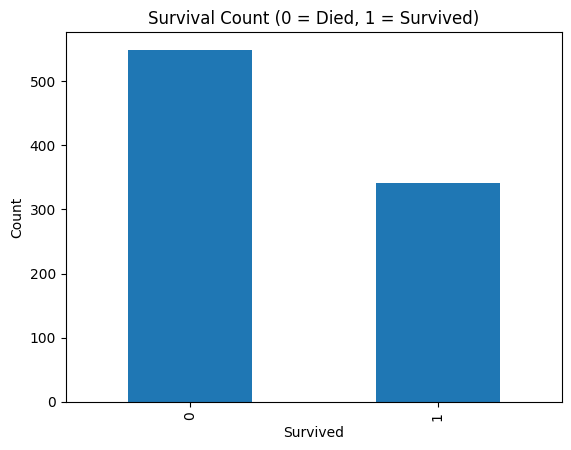

In [38]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count (0 = Died, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

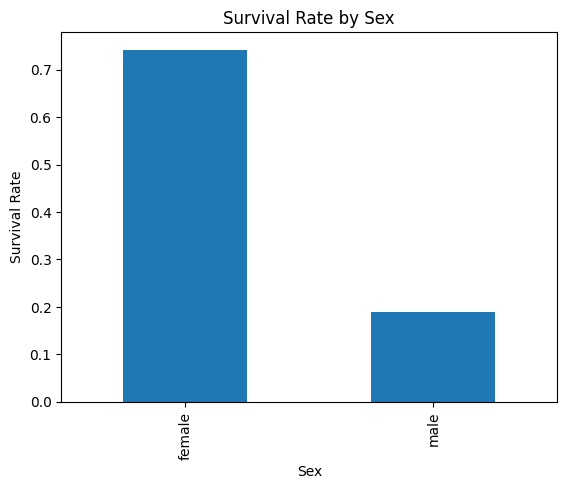

In [39]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

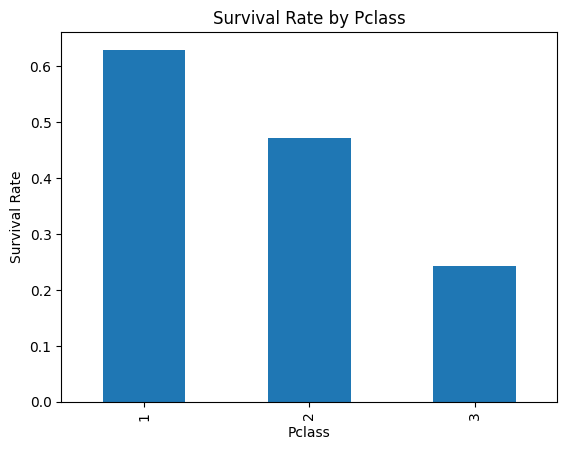

In [40]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Pclass")
plt.ylabel("Survival Rate")
plt.show()

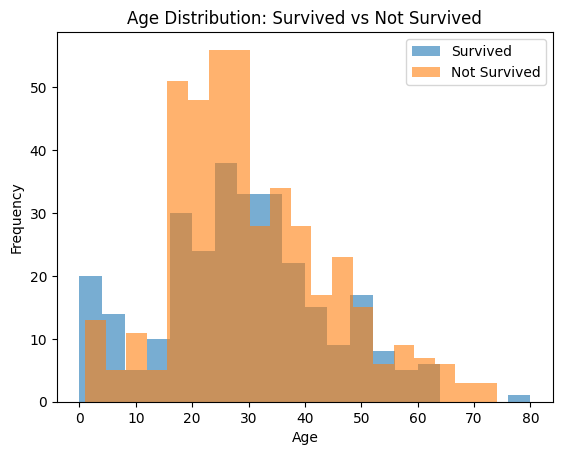

In [41]:
df[df["Survived"] == 1]["Age"].plot(kind="hist", bins=20, alpha=0.6, label="Survived")
df[df["Survived"] == 0]["Age"].plot(kind="hist", bins=20, alpha=0.6, label="Not Survived")

plt.title("Age Distribution: Survived vs Not Survived")
plt.xlabel("Age")
plt.legend()
plt.show()

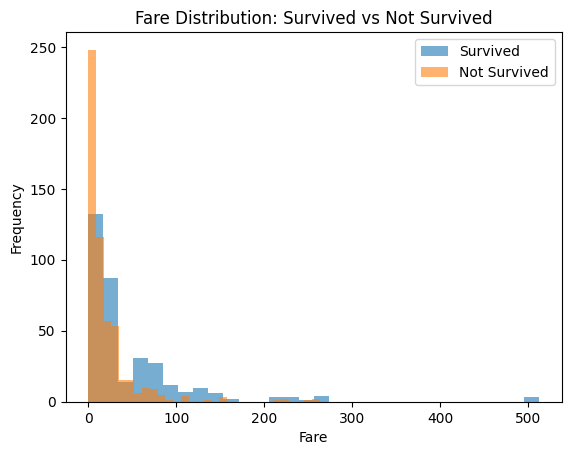

In [42]:
df[df["Survived"] == 1]["Fare"].plot(kind="hist", bins=30, alpha=0.6, label="Survived")
df[df["Survived"] == 0]["Fare"].plot(kind="hist", bins=30, alpha=0.6, label="Not Survived")

plt.title("Fare Distribution: Survived vs Not Survived")
plt.xlabel("Fare")
plt.legend()
plt.show()

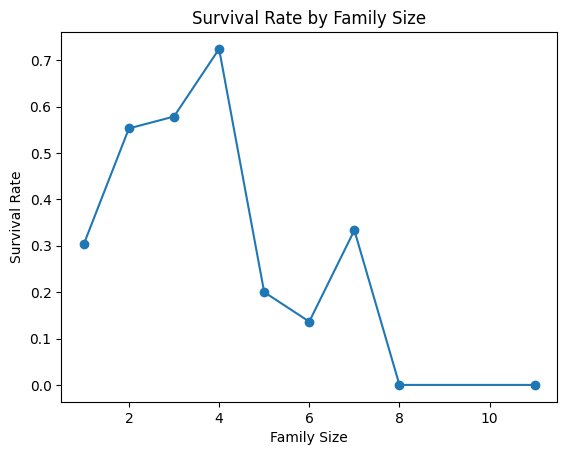

In [46]:
df.groupby("FamSize")["Survived"].mean().plot(kind="line", marker="o")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()